<a href="https://colab.research.google.com/github/tilangelo/ML.2025-26/blob/main/dz_5.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pymorphy3 gensim scikit-learn nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 103.6 MB/s eta 0:00:00


In [2]:
import sqlite3
import pandas as pd
import numpy as np

In [3]:
conn = sqlite3.connect("articles.db")
df = pd.read_sql("SELECT * FROM articles", conn)

In [4]:
df.head()

,guid,url,title,description,published_at,comments_count,rating,created_at_utc
0,5081222,https://www.hab.kp.ru/online/news/5081222/,Украли краденое: в Хабаровске избили и ограбил...,В Хабаровске завершили расследование уголовног...,2023-01-01T02:08:03,None,None,2025-12-15T11:42:38.381161500
1,5081227,https://www.hab.kp.ru/online/news/5081227/,В Магадане инспекторы начали ловить нетрезвых ...,Утро 1 января началось для госавтоинспекторов ...,2023-01-01T02:54:21,None,None,2025-12-15T11:42:36.355664600
2,5081231,https://www.hab.kp.ru/online/news/5081231/,«Забег обещаний» стартует в Хабаровске 1 января,В Хабаровске в первый день нового 2023 года тр...,2023-01-01T03:59:58,None,None,2025-12-15T11:42:34.241586100
3,5081241,https://www.hab.kp.ru/online/news/5081241/,Поживился на съемной квартире: житель Хабаровс...,В Хабаровске центральный районный суд вынес пр...,2023-01-01T05:02:51,None,None,2025-12-15T11:42:31.133534200
4,5081251,https://www.hab.kp.ru/online/news/5081251/,Прокуратура Хабаровского района контролирует х...,В Хабаровском крае прокуратура контролирует хо...,2023-01-01T05:50:07,None,None,2025-12-15T11:42:29.033054200


In [5]:
df.shape

(5291, 8)

In [6]:
df.isnull().sum()

,0
guid,0
url,0
title,0
description,0
published_at,0
comments_count,5291
rating,5291
created_at_utc,0


In [7]:
df.guid.nunique(), len(df)

(5291, 5291)

In [8]:
df["text"] = ( df["title"].fillna("") + " " + df["description"] )
df["text"] = df["text"].str.lower()
df["text"].iloc[0][:500]

'украли краденое: в хабаровске избили и ограбили курьера, работавшего на мошенников в хабаровске завершили расследование уголовного дела по статье за кражу и передали материалы в суд на рассмотрение по существу. как сообщает су ск россии по хабаровскому краю и еао, пятеро человек избили и забрали деньги у курьера, который работал на мошенников. курьер был несовершеннолетним.\n\n- завершено расследование уголовного дела в отношении 15-ти, 17-ти, 20-ти, 21- и 24-летних жителей города хабаровска и хаб'

In [9]:
from sklearn.impute import SimpleImputer

num_features = ["comments_count", "rating"]

imputer = SimpleImputer(strategy="constant", fill_value=0)
df[num_features] = imputer.fit_transform(df[num_features])

токенизируем текст для работы с w2v. С помощью реджекса делаем выборку только по словам, предлогам и тп, не учитывая знаки препинания и регистр.

In [10]:
import re

def tokenize(text):
    return re.findall(r"[а-яё]+", text.lower())

df["tokens"] = df["text"].apply(tokenize)
df["tokens"].iloc[0][:20]

['украли',
 'краденое',
 'в',
 'хабаровске',
 'избили',
 'и',
 'ограбили',
 'курьера',
 'работавшего',
 'на',
 'мошенников',
 'в',
 'хабаровске',
 'завершили',
 'расследование',
 'уголовного',
 'дела',
 'по',
 'статье',
 'за']

Создаём модель на выборке токенов, длина каждого вектора(слова) в 100 чисел.

In [11]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=df["tokens"],
    vector_size=100,
    window=5,
    min_count=5,
    workers=4
)

In [12]:
w2v_model.wv.most_similar("пожар")

[('случился', 0.9507637023925781),
 ('доме', 0.9327178597450256),
 ('произошел', 0.9263328909873962),
 ('вспыхнул', 0.9157552123069763),
 ('случилась', 0.9150227904319763),
 ('случилось', 0.9126342535018921),
 ('произошла', 0.9073540568351746),
 ('загорелся', 0.9055535197257996),
 ('авария', 0.9052661061286926),
 ('возгорание', 0.9045822620391846)]

собираем матрицу 5200x100. Векторы документов(строк) нужны для кластеризации. Вектор документа - среднее векторов всех слов строки(документа)

In [13]:
def document_vector(tokens, model):
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_w2v = np.vstack(
    df["tokens"].apply(lambda x: document_vector(x, w2v_model))
)


создаём модель. кластеры без родителя

In [14]:
from sklearn.cluster import KMeans

k = 10
kmeans = KMeans(n_clusters=k, random_state=111)
labels = kmeans.fit_predict(X_w2v)

добавляю к каждой строке(новости) кластер

In [16]:
df["cluster"] = labels
df["cluster"].value_counts()

,count
cluster,
8,796
9,779
7,715
0,566
5,518
6,480
4,456
2,450
1,367


In [17]:
for i in range(k):
    print(f"\n=== Кластер {i} ===")
    display(
        df[df.cluster == i][["title"]].head(5)
    )



=== Кластер 0 ===


,title
2,«Забег обещаний» стартует в Хабаровске 1 января
14,16 ледовых переправ открыто в Хабаровском крае
36,Роспотребнадзор по Хабаровскому краю: ситуация...
40,Встретили год поражением: хабаровский ХК «Амур...
54,Паромную переправу Ванино – Холмск закрыли из-...



=== Кластер 1 ===


,title
15,Более 12 тысяч детей появилось на свет в Хабар...
30,Предприниматели Хабаровского края перевыполнил...
41,Прожиточный минимум установлен на 2023 год в Х...
49,Проезд на восьми маршрутах ощутимо подорожает ...
51,Этап детского Кубка России по шахматам стартов...



=== Кластер 2 ===


...

,title
20,Мусор вывозят каждый день в новогодние выходны...
46,Хабаровчане с РАС могут освоить профессию в ИТ
60,Храмы и церкви перед Рождеством проверили спас...
66,Посетители парка «Динамо» приняли участие в ро...
67,Регулярный рейс из Хабаровска в Харбин запусти...



=== Кластер 8 ===


,title
0,Украли краденое: в Хабаровске избили и ограбил...
3,Поживился на съемной квартире: житель Хабаровс...
26,Неизвестный оформил микрозайм на жительницу Ма...
32,Ударил ножом родственника: подозреваемого заде...
34,Жительница Хабаровска перевела 900 тысяч рубле...



=== Кластер 9 ===


,title
7,В «Забеге обещаний» приняли участие 250 жителе...
13,Пятеро детей родились в Хабаровском крае в нов...
19,Крупных аварий не зафиксировано в первые дни 2...
28,"Михаил Дегтярев: гордимся учениками, студентам..."
35,Дети из Хабаровска безопасно отдыхают на зимни...


визуализирую кластеры

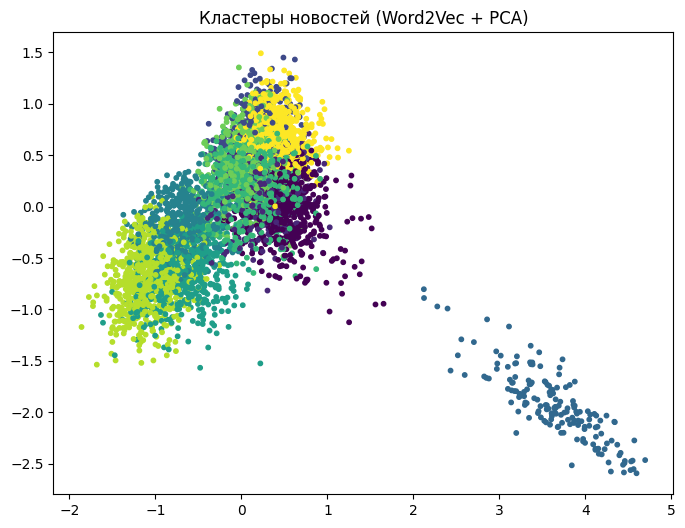

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_w2v)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["cluster"], s=10)
plt.title("Кластеры новостей (Word2Vec + PCA)")
plt.show()

In [19]:
df[df["cluster"] == 3][["title", "text"]].head(5)

,title,text
8,Пощады не будет: холодная погода не отпустит Х...,пощады не будет: холодная погода не отпустит х...
21,До -39 градусов упадет температура 3 января в ...,до -39 градусов упадет температура 3 января в ...
33,В Хабаровске будет холодно и без осадков 4 января,в хабаровске будет холодно и без осадков 4 янв...
44,38-градусный мороз ждет Хабаровский край 5 января,38-градусный мороз ждет хабаровский край 5 янв...
62,Стабильный минус: погода не готовит сюрпризов ...,стабильный минус: погода не готовит сюрпризов ...


In [21]:
from collections import Counter

cluster_id = 3

words = []
for tokens in df[df["cluster"] == cluster_id]["tokens"]:
    words.extend(tokens)

Counter(words).most_common(20)

[('в', 1615),
 ('до', 1352),
 ('от', 919),
 ('градусов', 781),
 ('днем', 676),
 ('ночью', 631),
 ('метров', 616),
 ('секунду', 584),
 ('на', 533),
 ('будет', 480),
 ('ветер', 441),
 ('и', 404),
 ('температура', 391),
 ('а', 335),
 ('края', 279),
 ('не', 273),
 ('районах', 269),
 ('осадков', 266),
 ('с', 209),
 ('ожидается', 206)]

Теперь supervised(предсказание кластера). Decision tree

In [22]:
from sklearn.model_selection import train_test_split
X = X_w2v
y = df["cluster"]

X = X_w2v
y = df["cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=111,
    stratify=y
)

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=111)

param_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"],
}

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
)

grid_dt.fit(X_train, y_train)

print("Лучшие параметры:", grid_dt.best_params_)
print("Лучший CV accuracy:", grid_dt.best_score_)

Лучшие параметры: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучший CV accuracy: 0.7726163994951847


In [24]:
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print("Точность:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Test accuracy: 0.7909319899244333
              precision    recall  f1-score   support

           0       0.79      0.72      0.75       170
           1       0.79      0.74      0.76       110
           2       0.65      0.74      0.69       135
           3       1.00      1.00      1.00        49
           4       0.72      0.75      0.74       137
           5       0.86      0.92      0.88       155
           6       0.71      0.67      0.69       144
           7       0.76      0.75      0.75       215
           8       0.93      0.89      0.91       239
           9       0.78      0.80      0.79       234

    accuracy                           0.79      1588
   macro avg       0.80      0.80      0.80      1588
weighted avg       0.79      0.79      0.79      1588



KNN

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": [3, 5, 10, 15],
    "weights": ["uniform", "distance"],
    "metric": ["cosine"],
}

grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
)

grid_knn.fit(X_train, y_train)

print("Лучшие параметры:", grid_knn.best_params_)
print("Лучший CV accuracy:", grid_knn.best_score_)

Лучшие параметры: {'metric': 'cosine', 'n_neighbors': 15, 'weights': 'distance'}
Лучший CV accuracy: 0.8755088069256797


In [26]:
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)

print("Точность:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Test accuracy: 0.896095717884131
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       170
           1       0.92      0.88      0.90       110
           2       0.91      0.85      0.88       135
           3       0.94      1.00      0.97        49
           4       0.92      0.79      0.85       137
           5       0.93      0.96      0.94       155
           6       0.90      0.76      0.82       144
           7       0.92      0.89      0.91       215
           8       0.92      0.99      0.95       239
           9       0.82      0.95      0.88       234

    accuracy                           0.90      1588
   macro avg       0.91      0.89      0.90      1588
weighted avg       0.90      0.90      0.90      1588

